# Incorporating Machine Learning For Binary Black Hole Merger Detection
How efficiently can a CNN trained on time-frequency spectrograms of real LIGO stellar-mass binary black hole mergers data compare to matched filtering?

1. Make the most general machine learning
2. Train a system to break down a data set, full LIGO data for each merger event, into small segment and evaluate the weight value for each segment
3. Train using that mechanism

# Import and install necessary libraries

In [8]:
pip install gwpy

Note: you may need to restart the kernel to use updated packages.


In [9]:
!python -m pip install gwpy

In [10]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [12]:
import numpy as np
from matplotlib import pyplot as plt
from gwpy.timeseries import TimeSeries
from gwpy.plot import Plot
from gwosc.datasets import event_gps
from scipy.ndimage import label

/opt/anaconda3/lib/python3.12/site-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


In [13]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Activation, Dropout, Input, Masking
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.metrics import Precision

In [16]:
pip install --upgrade scipy

Note: you may need to restart the kernel to use updated packages.


# Retrieve data
Use the GWOSC dataset library to access the information on binary black hole merger events

In [625]:
bh_merger = "GW230630_234532"
#GW150914
#GW170729
#GW170814
#GW191222_033537
#GW200129_065458

In [627]:
data_type = 'H1'

In [629]:
def retrieve_data(bh_merger):
    gps = event_gps(bh_merger)
    start = gps - 2.0
    end = gps + 2.0
    return gps, start, end

In [631]:
gps, start, end = retrieve_data(bh_merger)
print(gps)

1372203950.4


In [633]:
def get_data(bh_merger, data_type, shift):
    gps, start, end = retrieve_data(bh_merger)
    gps_shifted = gps + shift
    start = start + shift
    end = end + shift
    data = TimeSeries.fetch_open_data(data_type, start, end, cache=True)
    #print(data)
    return data, gps, gps_shifted

In [635]:
data, gps, gps_shifted = get_data(bh_merger, data_type, shift=0)

# Data Preprocessing
Use bandpass filter(20-500) and whiten to preprocess raw LIGO data

In [ ]:
def preprocess(data):
    white_data = data.whiten(fftlength=1, overlap=0.5)
    bp_data = white_data.bandpass(20, 500)
    return bp_data

In [ ]:
def make_hq(data):
    bp_data = preprocess(data)
    hq = bp_data.q_transform(qrange=(4,64), frange=(30,400), logf=True, whiten=True)
    return hq

In [638]:
hq = make_hq(data)

# Make label
Label the chirp with the greatest energy as 1, and label other pixels that compose the chirp with values (from 0-1) proportional to the maximum energy

Label background pixels as 0

In [639]:
def make_label(hq, gps, window_half, percentile):
    arr_full = hq.value.T.astype(np.float32, copy=False)
    center = int((gps - hq.xindex[0].value) / hq.dt.value)

    window_half_idx = int(window_half / hq.dt.value)
    
    start = max(0, center - window_half_idx)
    end = min(arr_full.shape[1], center + window_half_idx)
    arr_crop = arr_full[:, start:end]
    
    thr = np.nanpercentile(arr_crop, percentile)
    mask_crop = (arr_crop > thr).astype(np.uint8)
    
    labeled, num_features = label(mask_crop)
    if num_features == 0:
        return np.zeros_like(arr_crop, dtype=np.uint8), arr_crop

    sizes = [(i, (labeled == i).sum()) for i in range(1, num_features + 1)]
    best = max(sizes, key=lambda x: x[1])[0]
    mask_largest = (labeled == best).astype(np.uint8)
    return mask_largest, arr_crop

In [643]:
mask_largest, arr_crop = make_label(hq, gps, window_half=0.25, percentile=98.0)

In [647]:
def make_weighted_mask(mask_largest, arr_crop, gps, gps_shifted, threshold):
    weighted_mask = mask_largest.astype(np.float32) * arr_crop.astype(np.float32)

    '''print(f"gps={gps}, gps_shifted={gps_shifted}, threshold={threshold}")
    print(f"Check window range: {gps_shifted - threshold} < {gps} < {gps_shifted + threshold}")'''
    
    if gps_shifted-threshold < gps < gps_shifted+threshold:
        m = float(weighted_mask.max())
        '''print(f"Max of weighted_mask: {m}")'''
        if m > 0:
            weighted_mask = weighted_mask / m
        else:
            weighted_mask[:] = 0
        return weighted_mask
    else:
        '''print("GPS out of range; setting mask to zero.")'''
        weighted_mask[:] = 0
        return weighted_mask

In [649]:
weighted_mask = make_weighted_mask(mask_largest, arr_crop, gps, gps_shifted, threshold=0.27)

In [651]:
def plot(arr_crop, weighted_mask):
    t = (np.arange(arr_crop.shape[1]) - arr_crop.shape[1]//2) * hq.dt.value
    plt.figure(figsize=(10, 4))
    plt.imshow(arr_crop, aspect='auto', origin='lower', cmap='viridis', extent=[t[0], t[-1], 0, arr_crop.shape[0]])
    plt.title("Spectrogram [" + bh_merger + "]")
    plt.colorbar()
    plt.xlabel("Time")
    plt.ylabel("Frequency")
    
    plt.figure(figsize=(10, 4))
    plt.imshow(weighted_mask, aspect='auto', origin='lower', cmap='gray', extent=[t[0], t[-1], 0, arr_crop.shape[0]])
    plt.title("Label [" + bh_merger + "]")
    plt.colorbar()
    plt.xlabel("Time")
    plt.ylabel("Frequency")
    plt.show()

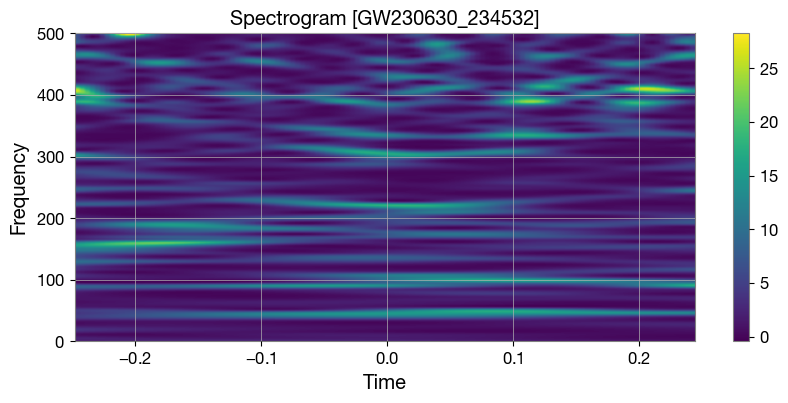

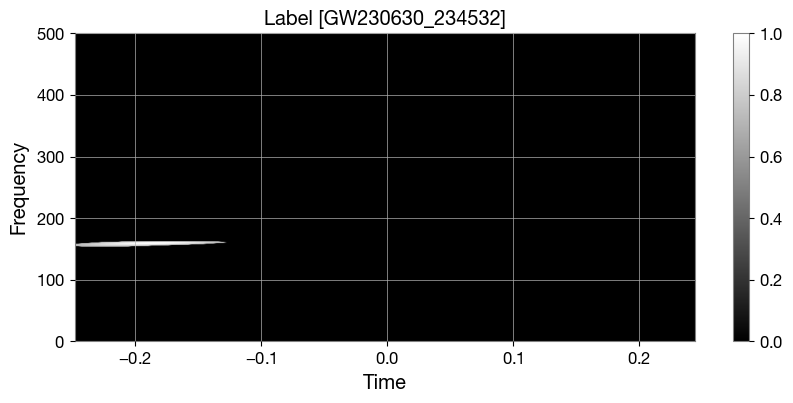

In [655]:
plot(arr_crop, weighted_mask)

In [657]:
def preprocess_event(event, data_type):
    data, gps, _ = get_data(event, data_type, shift=0)
    hq = make_hq(data)

    cache = {"hq": hq, "gps": gps}
    return cache

In [659]:
def create_example_from_cache(ev_cache, shift, window_half, percentile, plot_figs, threshold=0.27):
    """
    Create a single (X, Y) pair from a cached event, for a given time shift.
    """
    hq  = ev_cache["hq"]
    gps = ev_cache["gps"]
    gps_shifted = gps + shift
    mask_largest, arr_crop = make_label(hq, gps_shifted, window_half, percentile)
    arr_crop = np.asarray(arr_crop)
    mask_largest = np.asarray(mask_largest)
    arr_crop = np.nan_to_num(arr_crop, nan=0.0, posinf=0.0, neginf=0.0)
    mask_largest = np.nan_to_num(mask_largest, nan=0.0, posinf=0.0, neginf=0.0)
    weighted_mask = make_weighted_mask(mask_largest, arr_crop, gps, gps_shifted, threshold=threshold)
    if plot_figs:
        plot(arr_crop, weighted_mask)
    arr_crop = arr_crop.astype(np.float32, copy=False)
    weighted_mask = weighted_mask.astype(np.float32, copy=False)
    return arr_crop, weighted_mask

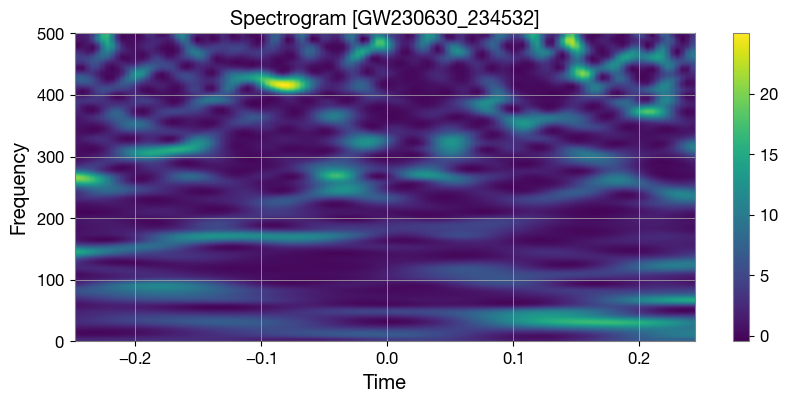

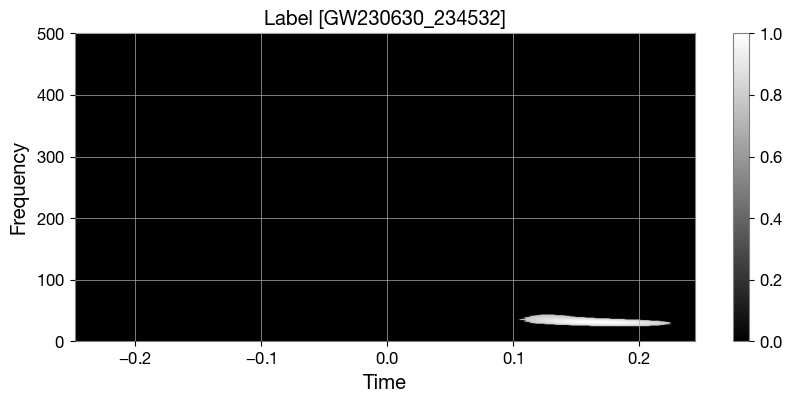

In [661]:
ev_cache = preprocess_event("GW230630_234532", "L1")
arr_crop, weighted_mask = create_example_from_cache(ev_cache, shift=0, window_half=0.25, percentile=98.0, plot_figs=True)

# Data organization
Divide the 129 binary black hole merger events from GWPY into three groups: (1) events that have both Hanford and Livingston data strain, (2) events that only have Hanford data strain, and (3) events that only have Livingston data strain

In [58]:
events_train_HL = ["GW150914", 
                   "GW151012", 
                   "GW151226", 
                   "GW170104",  
                   "GW170729", 
                   "GW170809", 
                   "GW170814", 
                   "GW170817", 
                   "GW170818", 
                   "GW170823", 
                   "GW190403_051519", 
                   "GW190408_181802", 
                   "GW190412", 
                   "GW190413_052954", 
                   "GW190413_134308", 
                   "GW190421_213856", 
                   "GW190426_190642", 
                   "GW190503_185404", 
                   "GW190512_180714", 
                   "GW190513_205428", 
                   "GW190514_065416", 
                   "GW190517_055101", 
                   "GW190519_153544", 
                   "GW190521", 
                   "GW190521_074359", 
                   "GW190527_092055", 
                   "GW190602_175927", 
                   "GW190701_203306", 
                   "GW190706_222641", 
                   "GW190707_093326", 
                   "GW190719_215514", 
                   "GW190720_000836", 
                   "GW190725_174728", 
                   "GW190727_060333", 
                   "GW190728_064510", 
                   "GW190731_140936", 
                   "GW190803_022701", 
                   "GW190805_211137", 
                   "GW190814", 
                   "GW190828_063405", 
                   "GW190828_065509", 
                   "GW190915_235702", 
                   "GW190916_200658", 
                   "GW190917_114630", 
                   "GW190924_021846", 
                   "GW190926_050336", 
                   "GW190929_012149", 
                   "GW190930_133541", 
                   "GW191103_012549", 
                   "GW191105_143521", 
                   "GW191109_010717", 
                   "GW191113_071753", 
                   "GW191126_115259", 
                   "GW191127_050227", 
                   "GW191129_134029", 
                   "GW191204_110529", 
                   "GW191204_171526", 
                   "GW191215_223052", 
                   "GW191219_163120", 
                   "GW191222_033537", 
                   "GW191230_180458", 
                   "GW200115_042309", 
                   "GW200128_022011", 
                   "GW200129_065458", 
                   "GW200202_154313", 
                   "GW200208_130117", 
                   "GW200208_222617", 
                   "GW200209_085452", 
                   "GW200210_092254", 
                   "GW200216_220804", 
                   "GW200219_094415", 
                   "GW200220_061928", 
                   "GW200220_124850", 
                   "GW200224_222234", 
                   "GW200225_060421", 
                   "GW200306_093714", 
                   "GW200308_173609", 
                   "GW200311_115853", 
                   "GW200316_215756", 
                   "GW200322_091133", 
                   "GW230518_125908", 
                   "GW230601_224134", 
                   "GW230603_174756", 
                   "GW230605_065343", 
                   "GW230606_004305", 
                   "GW230606_024545", 
                   "GW230608_205047", 
                   "GW230609_010824", 
                   "GW230609_064958", 
                   "GW230615_160825", 
                   "GW230618_102550", 
                   "GW230624_113103", 
                   "GW230625_211655", 
                   "GW230627_015337", 
                   "GW230628_231200", 
                   "GW230630_070659", 
                   "GW230630_125806", 
                   "GW230630_234532", 
                   "GW230702_162025", 
                   "GW230702_185453", 
                   "GW230704_021211", 
                   "GW230704_212616", 
                   "GW230706_104333", 
                   "GW230707_124047", 
                   "GW230708_053705", 
                   "GW230708_071859", 
                   "GW230708_230935", 
                   "GW230709_063445", 
                   "GW230709_122727", 
                   "GW230712_090405", 
                   "GW230717_102139", 
                   "GW230721_222634", 
                   "GW230723_084820", 
                   "GW230723_101834", 
                   "GW230728_083628", 
                   "GW230729_082317", 
                   "GW230731_215307", 
                   "GW230803_033412", 
                   "GW230805_034249", 
                   "GW230806_204041", 
                   "GW230807_205045", 
                   "GW230811_032116", 
                   "GW230814_061920", 
                   "GW230817_212349", 
                   "GW230819_171910", 
                   "GW230820_212515", 
                   "GW230822_230337", 
                   "GW230823_142524", 
                   "GW230824_033047", 
                   "GW230824_135331", 
                   "GW230825_041334", 
                   "GW230830_064744", 
                   "GW230831_015414", 
                   "GW230831_134621", 
                   "GW230902_122814", 
                   "GW230902_172430", 
                   "GW230902_224555", 
                   "GW230904_051013"] 

In [59]:
events_train_H = ["GW190925_232845", 
                  "GW191216_213338", 
                  "GW200302_015811", 
                  "GW230624_214944"]

In [60]:
events_train_L = ["GW170608", 
                  "GW190425", 
                  "GW190620_030421", 
                  "GW190630_185205", 
                  "GW190708_232457", 
                  "GW190910_112807", 
                  "GW200112_155838", 
                  "GW230529_181500", 
                  "GW230531_141100", 
                  "GW230726_002940", 
                  "GW230814_230901"]

In [61]:
events_dev_HL = ["GW230904_152545", 
                 "GW230914_111401", 
                 "GW230919_215712", 
                 "GW230920_064709", 
                 "GW230920_071124", 
                 "GW230922_020344", 
                 "GW230922_040658", 
                 "GW230924_124453", 
                 "GW230925_143957", 
                 "GW230927_043729", 
                 "GW230927_153832", 
                 "GW230928_215827", 
                 "GW230930_110730", 
                 "GW231001_140220", 
                 "GW231002_143916", 
                 "GW231004_232346", 
                 "GW231005_021030", 
                 "GW231005_091549", 
                 "GW231005_144455", 
                 "GW231008_142521", 
                 "GW231013_135504", 
                 "GW231014_040532", 
                 "GW231018_233037", 
                 "GW231020_142947", 
                 "GW231026_130704", 
                 "GW231028_153006", 
                 "GW231102_052214", 
                 "GW231102_071736", 
                 "GW231102_232433", 
                 "GW231104_133418", 
                 "GW231108_125142"]

In [62]:
events_dev_H = ["GW230911_195324"]

In [63]:
events_dev_L = ["GW231029_111508"]

In [64]:
events_test_HL = ["GW231110_040320", 
                  "GW231113_122623", 
                  "GW231113_150041", 
                  "GW231113_200417", 
                  "GW231114_043211", 
                  "GW231118_005626", 
                  "GW231118_071402", 
                  "GW231118_090602", 
                  "GW231119_075248", 
                  "GW231120_022103", 
                  "GW231123_135430", 
                  "GW231126_010928", 
                  "GW231127_165300", 
                  "GW231129_081745", 
                  "GW231204_090648", 
                  "GW231206_010629", 
                  "GW231206_233134", 
                  "GW231206_233901", 
                  "GW231213_111417", 
                  "GW231220_173406", 
                  "GW231221_135041", 
                  "GW231223_032836", 
                  "GW231223_075055", 
                  "GW231224_024321", 
                  "GW231226_101520", 
                  "GW231230_170116", 
                  "GW231231_120147", 
                  "GW240107_013215"]

In [65]:
events_test_H = ["GW231231_154016", 
                 "GW231223_202619", 
                 "GW240104_164932", 
                 "GW240105_151143", 
                 "GW240109_050431"]

In [66]:
print(len(events_train_HL))
print(len(events_train_H))
print(len(events_train_L))
print(len(events_dev_HL))
print(len(events_dev_H))
print(len(events_dev_L))
print(len(events_test_HL))
print(len(events_test_H))
print(len(events_train_HL) + len(events_train_H) + len(events_train_L) + len(events_dev_HL) + len(events_dev_H) + len(events_dev_L) + len(events_test_HL) + len(events_test_H))

138
4
11
31
1
1
28
5
219


In [67]:
shifts = [0.0, -0.1, 0.1, -0.2, 0.2, 1.5]

In [68]:
def create_training_samples(event_set, data_type, X_set, Y_set):
    for i in range(0, len(event_set)):
        print(i)
        ev_cache = preprocess_event(event_set[i], data_type)
        for s in shifts:
            arr_crop, weighted_mask = create_example_from_cache(ev_cache, shift=s, window_half=0.25, percentile=98.0, plot_figs=False)
            X_set.append(arr_crop.swapaxes(0, 1))
            Y_set.append(weighted_mask.swapaxes(0, 1))

In [69]:
X_train = []
Y_train = []

In [72]:
create_training_samples(events_train_HL, "H1", X_train, Y_train)

0
1


KeyboardInterrupt: 

In [214]:
create_training_samples(events_train_HL, "L1", X_train, Y_train)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137


In [215]:
create_training_samples(events_train_H, "H1", X_train, Y_train)

0
1
2
3


In [216]:
create_training_samples(events_train_L, "L1", X_train, Y_train)

0
1
2
3
4
5
6
7
8
9
10


In [217]:
X_train = np.array(X_train, dtype=np.float32)
Y_train = np.array(Y_train, dtype=np.float32)

print(X_train.shape)
print(Y_train.shape)

np.save(f'./UV_train/U_train.npy', X_train)
np.save(f'./UV_train/V_train.npy', Y_train)

#expected shape: (2910, 124, 500)

(1746, 124, 500)
(1746, 124, 500)


In [218]:
X_dev = []

In [219]:
Y_dev = []

In [220]:
create_training_samples(events_dev_HL, "H1", X_dev, Y_dev)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30


In [221]:
create_training_samples(events_dev_HL, "L1", X_dev, Y_dev)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30


In [222]:
create_training_samples(events_dev_H, "H1", X_dev, Y_dev)

0


In [223]:
create_training_samples(events_dev_L, "L1", X_dev, Y_dev)

0


In [224]:
X_dev = np.array(X_dev, dtype=np.float32)
Y_dev = np.array(Y_dev, dtype=np.float32)

print(X_dev.shape)
print(Y_dev.shape)

np.save(f'./UV_dev/U_dev.npy', X_dev)
np.save(f'./UV_dev/V_dev.npy', Y_dev)

#expected shape: (640, 124, 500)

(384, 124, 500)
(384, 124, 500)


In [225]:
X_test = []

In [226]:
Y_test = []

In [227]:
create_training_samples(events_test_HL, "H1", X_test, Y_test)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27


In [228]:
create_training_samples(events_test_HL, "L1", X_test, Y_test)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27


In [229]:
create_training_samples(events_test_H, "H1", X_test, Y_test)

0
1
2
3
4


In [230]:
X_test = np.array(X_test, dtype=np.float32)
Y_test = np.array(Y_test, dtype=np.float32)

print(X_test.shape)
print(Y_test.shape)

np.save(f'./UV_test/U_test.npy', X_test)
np.save(f'./UV_test/V_test.npy', Y_test)

#expected shape: (610, 124, 500)

(366, 124, 500)
(366, 124, 500)


In [74]:
X_train = np.load(f'./UV_train/U_train.npy')
Y_train = np.load(f'./UV_train/V_train.npy')
X_dev = np.load(f'./UV_dev/U_dev.npy')
Y_dev = np.load(f'./UV_dev/V_dev.npy')
X_test = np.load(f'./UV_test/U_test.npy')
Y_test = np.load(f'./UV_test/V_test.npy')
X_train = np.reshape(X_train, (1746, 124, 500, 1))
Y_train = np.reshape(Y_train, (1746, 124, 500, 1))
X_dev = np.reshape(X_dev, (384, 124, 500, 1))
Y_dev = np.reshape(Y_dev, (384, 124, 500, 1))
X_test = np.reshape(X_test, (366, 124, 500, 1))
Y_test = np.reshape(Y_test, (366, 124, 500, 1))
X_train = tf.image.resize(X_train, [128, 500])
Y_train = tf.image.resize(Y_train, [128, 500])
X_dev = tf.image.resize(X_dev, [128, 500])
Y_dev = tf.image.resize(Y_dev, [128, 500])
X_test = tf.image.resize(X_test, [128, 500])
Y_test = tf.image.resize(Y_test, [128, 500])
print(X_train.shape)
print(Y_train.shape)
print(X_dev.shape)
print(Y_dev.shape)
print(X_test.shape)
print(Y_test.shape)

(1746, 128, 500, 1)
(1746, 128, 500, 1)
(384, 128, 500, 1)
(384, 128, 500, 1)
(366, 128, 500, 1)
(366, 128, 500, 1)


In [75]:
W_0 = 1.0    # Weight for the negative class (Background)
W_1 = 499.0  # Weight for the positive class (Chirp)

def weighted_binary_crossentropy(y_true, y_pred):
    """
    Custom loss function: Weighted Binary Cross-Entropy
    Applies weights W_0 and W_1 to the standard BCE calculation.
    """
    bce = K.binary_crossentropy(y_true, y_pred)
    weights = y_true * W_1 + (1. - y_true) * W_0
    weighted_bce = bce * weights
    return K.mean(weighted_bce)

# Evaluation metrics
Use IoU metric and F1 score to evaluate the model

In [78]:
def soft_iou_metric(y_true, y_pred, smooth=1e-5):
    y_pred = K.sigmoid(y_pred) 
    y_pred = K.clip(y_pred, K.epsilon(), 1. - K.epsilon())

    intersection = K.sum(y_true * y_pred, axis=[1,2,3])
    union = K.sum(y_true, axis=[1,2,3]) + K.sum(y_pred, axis=[1,2,3]) - intersection
    
    iou = (intersection + smooth) / (union + smooth)
    return K.mean(iou)

def soft_dice_coef(y_true, y_pred, smooth=1e-5):
    y_pred = K.sigmoid(y_pred)
    y_pred = K.clip(y_pred, K.epsilon(), 1. - K.epsilon())
    
    intersection = K.sum(y_true * y_pred, axis=[1,2,3])
    total = K.sum(y_true, axis=[1,2,3]) + K.sum(y_pred, axis=[1,2,3])
    
    dice = (2. * intersection + smooth) / (total + smooth)
    return K.mean(dice)

def tversky_loss(beta=0.7):
    def loss(y_true, y_pred):
        y_pred = K.sigmoid(y_pred)
        y_pred = K.clip(y_pred, K.epsilon(), 1. - K.epsilon())
        alpha = 1.0 - beta 
        y_true_f = K.flatten(y_true)
        y_pred_f = K.flatten(y_pred)
        
        true_pos = K.sum(y_true_f * y_pred_f)
        false_neg = K.sum(y_true_f * (1 - y_pred_f))
        false_pos = K.sum((1 - y_true_f) * y_pred_f)
        
        tversky_index = (true_pos + K.epsilon()) / (true_pos + alpha * false_pos + beta * false_neg + K.epsilon())
        
        return 1.0 - tversky_index
    return loss

def combined_focal_dice_loss(y_true, y_pred):
    f_loss = focal_loss(gamma=2.0, alpha=0.75)(y_true, y_pred)
    dice_loss = 1.0 - soft_dice_coef(y_true, y_pred)
    
    # Give Dice Loss 2x or 3x more importance to force the model to find the shape
    return f_loss + (2.0 * dice_loss)

# Train

In [80]:
from tensorflow.keras import layers, models, Input
from tensorflow.keras.callbacks import EarlyStopping

Tx = 128
n_freq = 500

def build_model(n_freq, Tx):
    inp = Input(shape=(Tx, n_freq, 1))
    x = layers.Conv2D(32, (3,3), padding="same", activation="relu")(inp)
    x = layers.Dropout(0.3)(x)
    x = layers.Conv2D(64, (3,3), padding="same", activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Conv2D(128, (3,3), padding="same", activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Conv2D(128, (3,3), padding="same", activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Conv2D(1, (1,1), padding="same")(x)
    return models.Model(inp, out)

model = build_model(n_freq, Tx)

In [82]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# 1. Reduce LR if validation loss doesn't improve for 2 epochs
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,          # Drop LR to 20% of current value
    patience=2,          # Wait 2 epochs before dropping
    min_lr=1e-7,
    verbose=1
)

# 2. Stop training if no improvement after 5 epochs (prevents overfitting)
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True # Go back to the best epoch, not the last one
)

In [86]:
from tensorflow.keras import backend as K

model = build_model(n_freq, Tx)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tversky_loss(beta=0.9),
    metrics=['accuracy', soft_iou_metric, soft_dice_coef]
)

cp = tf.keras.callbacks.ModelCheckpoint(
    "my_model.keras",
    monitor="val_dice_coef",  # or val_iou_metric
    mode="max",
    save_best_only=True,
    save_weights_only=False
)

history = model.fit(
    X_train,
    Y_train,
    epochs=10,
    batch_size=16,
    validation_data=(X_dev, Y_dev),
    callbacks=[lr_scheduler, early_stopping, cp],
    verbose=1
)

Epoch 1/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 588ms/step - accuracy: 0.7977 - loss: 0.8067 - soft_dice_coef: 0.0655 - soft_iou_metric: 0.0377

2026-01-01 11:00:59.020022: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


110/110 ━━━━━━━━━━━━━━━━━━━━ 70s 623ms/step - accuracy: 0.8992 - loss: 0.6142 - soft_dice_coef: 0.1596 - soft_iou_metric: 0.0976 - val_accuracy: 0.9885 - val_loss: 0.6550 - val_soft_dice_coef: 0.2517 - val_soft_iou_metric: 0.1702 - learning_rate: 0.0010
Epoch 2/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 73s 665ms/step - accuracy: 0.9764 - loss: 0.3061 - soft_dice_coef: 0.3433 - soft_iou_metric: 0.2252 - val_accuracy: 0.9883 - val_loss: 0.5901 - val_soft_dice_coef: 0.2928 - val_soft_iou_metric: 0.2004 - learning_rate: 0.0010
Epoch 3/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 68s 618ms/step - accuracy: 0.9777 - loss: 0.2890 - soft_dice_coef: 0.3591 - soft_iou_metric: 0.2392 - val_accuracy: 0.9876 - val_loss: 0.4976 - val_soft_dice_coef: 0.3227 - val_soft_iou_metric: 0.2271 - learning_rate: 0.0010
Epoch 4/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 70s 635ms/step - accuracy: 0.9772 - loss: 0.2906 - soft_dice_coef: 0.3632 - soft_iou_metric: 0.2426 - val_accuracy: 0.9866 - val_loss: 0.4264 - val_soft_dice_coef: 0.3757 - val

# Results

In [88]:
results = model.evaluate(X_test, Y_test, verbose=1)

test_loss = results[0]
test_accuracy = results[1]
test_iou = results[2]
test_dice = results[3]

2026-01-01 11:13:23.256435: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 285ms/step - accuracy: 0.9835 - loss: 0.3934 - soft_dice_coef: 0.3602 - soft_iou_metric: 0.2478


In [90]:
y = Y_test  # shape (N, H, W, 1)
pos = np.sum(y)
neg = np.prod(y.shape) - pos
print("Positive pixel fraction:", pos / (pos + neg))

Positive pixel fraction: 0.0058946193007172135


In [584]:
event_index = 120

In [586]:
spec_display = np.transpose(X_test[event_index, :, :, 0])
ground_truth = np.transpose(Y_test[event_index, :, :, 0])
pred_mask = np.transpose(model.predict(X_test)[event_index, :, :, 0])

12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 278ms/step


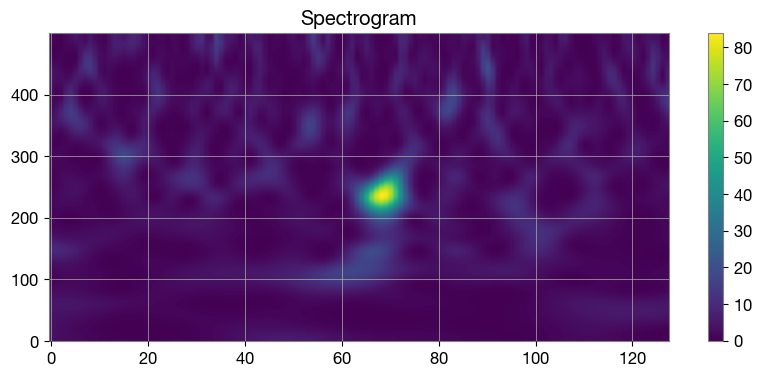

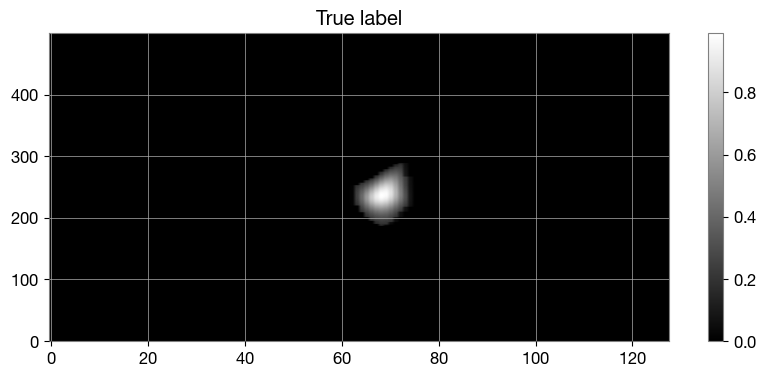

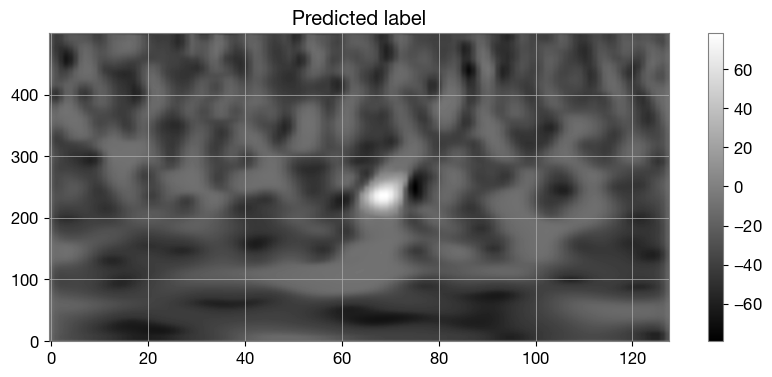

In [587]:
plt.figure(figsize=(10, 4))
plt.imshow(spec_display, origin="lower", aspect="auto", cmap="viridis")
plt.title("Spectrogram")
plt.colorbar()
plt.show()

plt.figure(figsize=(10, 4))
plt.imshow(ground_truth, origin="lower", aspect="auto", cmap="grey")
plt.title("True label")
plt.colorbar()
plt.show()

plt.figure(figsize=(10, 4))
plt.imshow(pred_mask, origin="lower", aspect="auto", cmap="grey")
plt.title("Predicted label")
plt.colorbar()
plt.show()